In [ ]:
!pip install mne

In [ ]:
import os

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/data.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    names = z.namelist()

In [ ]:
import zipfile, os

extract_path = '/content/chb01_data'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

data_dir = os.path.join(extract_path, 'data')
for f in sorted(os.listdir(data_dir)):
    print(f)

.DS_Store
chb01-summary.txt
chb01_01.edf
chb01_03.edf
chb01_03.edf.seizures
chb01_04.edf
chb01_04.edf.seizures
chb01_05.edf
chb01_15.edf
chb01_15.edf.seizures
chb01_16.edf
chb01_16.edf.seizures
chb01_18.edf
chb01_18.edf.seizures
chb01_21.edf
chb01_21.edf.seizures
chb01_26.edf
chb01_26.edf.seizures


In [ ]:
import mne

edf_path = os.path.join(data_dir, 'chb01_16.edf')
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)

Extracting EDF parameters from /content/chb01_data/data/chb01_16.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_657/1558473656.py:4: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)


In [ ]:
raw

<RawEDF | chb01_16.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [ ]:
print("\nChannel names:")
print(raw.ch_names)
print("\nSample rate:", raw.info['sfreq'])
print("Duration (s):", raw.n_times / raw.info['sfreq'])


Channel names:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

Sample rate: 256.0
Duration (s): 3600.0


In [ ]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-07 02:44:51 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>

# isolating the 4 channels as given in paper, in a copied raw file

In [ ]:
target_channels = ['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']

raw_4ch = raw.copy().pick(target_channels)
print(raw_4ch.ch_names)

['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']


In [ ]:
summary_path = os.path.join(data_dir, 'chb01-summary.txt')
with open(summary_path, 'r') as f:
    lines = f.readlines()

In [ ]:
capture = False
for line in lines:
    if 'chb01_16.edf' in line:
        capture = True
    if capture:
        print(line.rstrip())
    if capture and 'File End Time' in line and 'chb01_17' not in line:
        pass  # keep going until we hit seizure info
    if capture and line.strip() == '' :
        break

File Name: chb01_16.edf
File Start Time: 02:44:51
File End Time: 3:44:51
Number of Seizures in File: 1
Seizure Start Time: 1015 seconds
Seizure End Time: 1066 seconds



In [ ]:
raw_4ch.info.keys()

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])

In [ ]:
raw_4ch.info["projs"]

[]

no projections, so either there's not much noise to supress, or direct sensor channel data is used here, NO ICA has been used

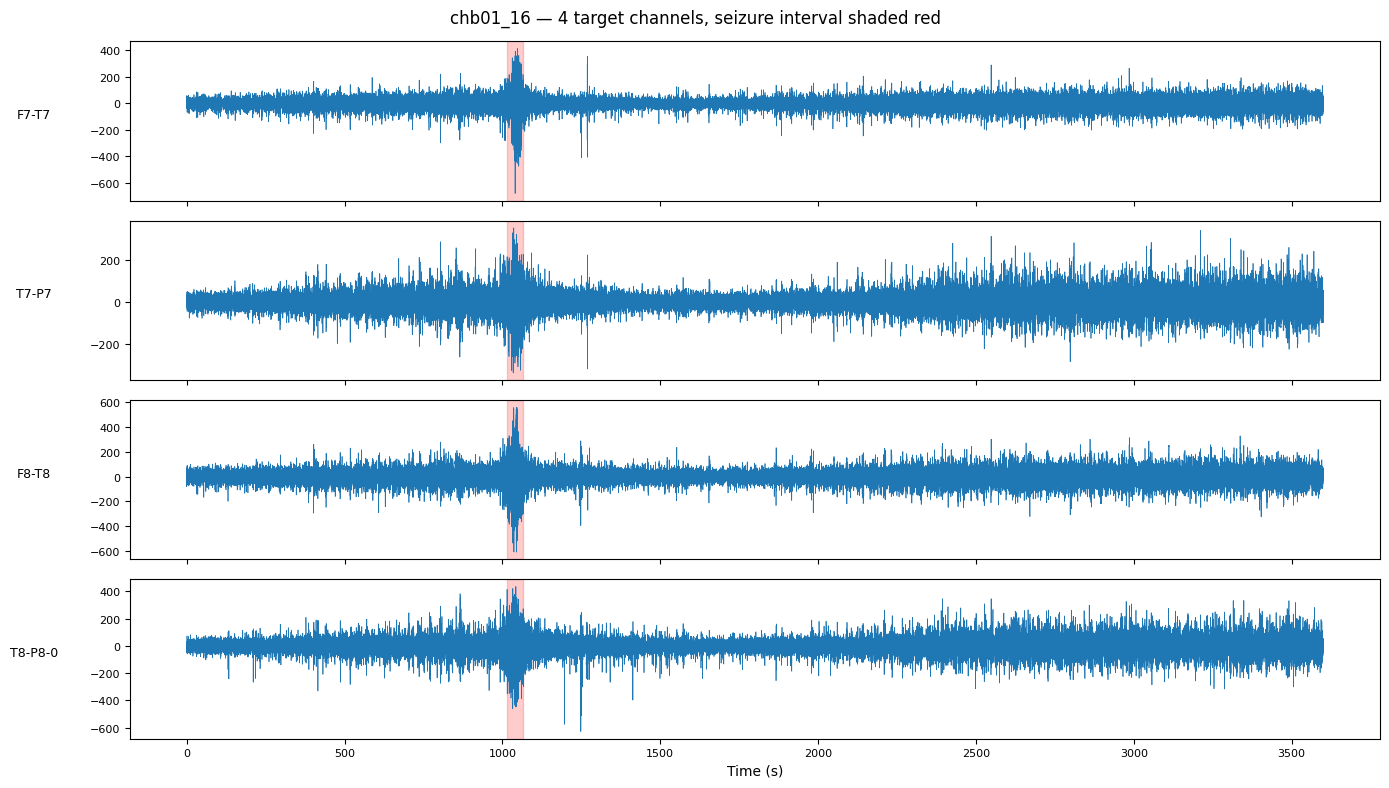

In [ ]:
sfreq = raw_4ch.info['sfreq']
data, times = raw_4ch.get_data(return_times=True)  # shape: (4, n_samples)

seizure_start, seizure_end = 1015, 1066

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for i, ch_name in enumerate(target_channels):
    axes[i].plot(times, data[i] * 1e6, linewidth=0.5)  # volts -> microvolts
    axes[i].axvspan(seizure_start, seizure_end, color='red', alpha=0.2)
    axes[i].set_ylabel(ch_name, rotation=0, labelpad=40, fontsize=9)
    axes[i].tick_params(labelsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('chb01_16 — 4 target channels, seizure interval shaded red')
plt.tight_layout()
plt.savefig('/content/chb01_16_4channels.png', dpi=120)
plt.show()

# step 1

In [ ]:
edf_path = os.path.join(data_dir, 'chb01_16.edf')
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)

Extracting EDF parameters from /content/chb01_data/data/chb01_16.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_657/1442087836.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=True)


In [ ]:
target_channels = ['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']

raw_4ch = raw.copy().pick(target_channels)
print(raw_4ch.ch_names)

['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']


In [ ]:
# Step 1: load chb01_03, get first 5 minutes, same 4 channels, to compute reference min/max
ref_path = os.path.join(data_dir, 'chb01_03.edf')
raw_ref = mne.io.read_raw_edf(ref_path, preload=True, verbose=False)
raw_ref_4ch = raw_ref.copy().pick(target_channels)

ref_data = raw_ref_4ch.get_data(tmin=0, tmax=300)  # first 5 min, shape (4, n_samples)
ref_data_uv = ref_data * 1e6  # convert to microvolts

ch_min = ref_data_uv.min(axis=1)  # per-channel min
ch_max = ref_data_uv.max(axis=1)  # per-channel max

for i, ch in enumerate(target_channels):
    print(f"{ch}: min={ch_min[i]:.2f} uV, max={ch_max[i]:.2f} uV")

/tmp/ipykernel_657/682938984.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_ref = mne.io.read_raw_edf(ref_path, preload=True, verbose=False)


F7-T7: min=-232.67 uV, max=181.49 uV
T7-P7: min=-244.79 uV, max=154.14 uV
F8-T8: min=-198.29 uV, max=192.43 uV
T8-P8-0: min=-165.86 uV, max=170.94 uV


# step 1 replicate

In [ ]:
ref_path2 = os.path.join(data_dir, 'chb01_01.edf')
raw_ref2 = mne.io.read_raw_edf(ref_path2, preload=True, verbose=False)
raw_ref_4ch2 = raw_ref2.copy().pick(target_channels)

/tmp/ipykernel_657/2333923377.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_ref2 = mne.io.read_raw_edf(ref_path2, preload=True, verbose=False)


In [ ]:
ref_data2 = raw_ref_4ch2.get_data(tmin = 0, tmax = 1)
ref_data_uv2 = ref_data2 * 1e6
ch_min2 = ref_data_uv2.min(axis=1)  # per-channel min
ch_max2 = ref_data_uv2.max(axis=1)
print(ch_min2.shape)

(4,)


# Step 2: original

In [ ]:
n_levels = 16
n_core_levels = 12  # levels 2 through 13 span [min, max]

step = (ch_max - ch_min) / n_core_levels
print("Step sizes (uV):")
for i, ch in enumerate(target_channels):
    print(f"{ch}: step={step[i]:.2f} uV")

# bin edges: 16 levels -> 15 edges internally, but we want 16 bins total
# min maps to level index 2 (0-indexed among 16 levels), max maps to level 13
# so levels 0,1 are below min (headroom), levels 14,15 are above max (headroom)
bin_edges = np.zeros((4, n_levels + 1))  # 17 edges -> 16 bins, per channel
for i in range(4):
    start = ch_min[i] - 2 * step[i]
    edges = start + step[i] * np.arange(n_levels + 1)
    bin_edges[i] = edges

for i, ch in enumerate(target_channels):
    print(f"\n{ch} bin edges (uV):")
    print(np.round(bin_edges[i], 2))

Step sizes (uV):
F7-T7: step=34.51 uV
T7-P7: step=33.24 uV
F8-T8: step=32.56 uV
T8-P8-0: step=28.07 uV

F7-T7 bin edges (uV):
[-301.7  -267.19 -232.67 -198.16 -163.65 -129.13  -94.62  -60.11  -25.59
    8.92   43.44   77.95  112.46  146.98  181.49  216.    250.52]

T7-P7 bin edges (uV):
[-311.27 -278.03 -244.79 -211.54 -178.3  -145.05 -111.81  -78.57  -45.32
  -12.08   21.16   54.41   87.65  120.9   154.14  187.38  220.63]

F8-T8 bin edges (uV):
[-263.41 -230.85 -198.29 -165.73 -133.17 -100.61  -68.05  -35.49   -2.93
   29.63   62.19   94.75  127.31  159.87  192.43  224.99  257.55]

T8-P8-0 bin edges (uV):
[-221.99 -193.93 -165.86 -137.79 -109.73  -81.66  -53.59  -25.53    2.54
   30.61   58.67   86.74  114.81  142.87  170.94  199.01  227.07]


# step 2 replication with 32 bins

In [ ]:
n_levels2 = 32
n_core_levels2 = 24  # levels 2 through 13 span [min, max]

step2 = (ch_max2 - ch_min2) / n_core_levels2
print("Step sizes (uV):")
for i, ch in enumerate(target_channels):
    print(f"{ch}: step={step2[i]:.2f} uV")

# bin edges: 32 levels -> 31 edges internally, but we want 32 bins total
# min maps to level index 2 (0-indexed among 16 levels), max maps to level 33
# so levels 0,1...8 are below min (headroom), levels 25...31,32 are above max (headroom)
bin_edges2 = np.zeros((4, n_levels2 + 1))  # 17 edges -> 16 bins, per channel
for i in range(4):
    start2 = ch_min2[i] - 4 * step2[i]
    edges2 = start2 + step2[i] * np.arange(n_levels2 + 1)
    bin_edges2[i] = edges2

for i, ch in enumerate(target_channels):
    print(f"\n{ch} bin edges (uV):")
    print(np.round(bin_edges2[i], 2))

Step sizes (uV):
F7-T7: step=7.62 uV
T7-P7: step=5.78 uV
F8-T8: step=6.40 uV
T8-P8-0: step=5.99 uV

F7-T7 bin edges (uV):
[-134.99 -127.37 -119.76 -112.14 -104.52  -96.9   -89.28  -81.66  -74.04
  -66.42  -58.8   -51.18  -43.57  -35.95  -28.33  -20.71  -13.09   -5.47
    2.15    9.77   17.39   25.01   32.63   40.24   47.86   55.48   63.1
   70.72   78.34   85.96   93.58  101.2   108.82]

T7-P7 bin edges (uV):
[-75.67 -69.89 -64.11 -58.33 -52.55 -46.77 -40.99 -35.21 -29.43 -23.65
 -17.88 -12.1   -6.32  -0.54   5.24  11.02  16.8   22.58  28.36  34.14
  39.92  45.7   51.48  57.26  63.04  68.82  74.6   80.37  86.15  91.93
  97.71 103.49 109.27]

F8-T8 bin edges (uV):
[-121.9  -115.51 -109.11 -102.71  -96.31  -89.91  -83.52  -77.12  -70.72
  -64.32  -57.92  -51.53  -45.13  -38.73  -32.33  -25.93  -19.54  -13.14
   -6.74   -0.34    6.06   12.45   18.85   25.25   31.65   38.05   44.44
   50.84   57.24   63.64   70.04   76.43   82.83]

T8-P8-0 bin edges (uV):
[-110.51 -104.52  -98.53  -92.54  

# step 3

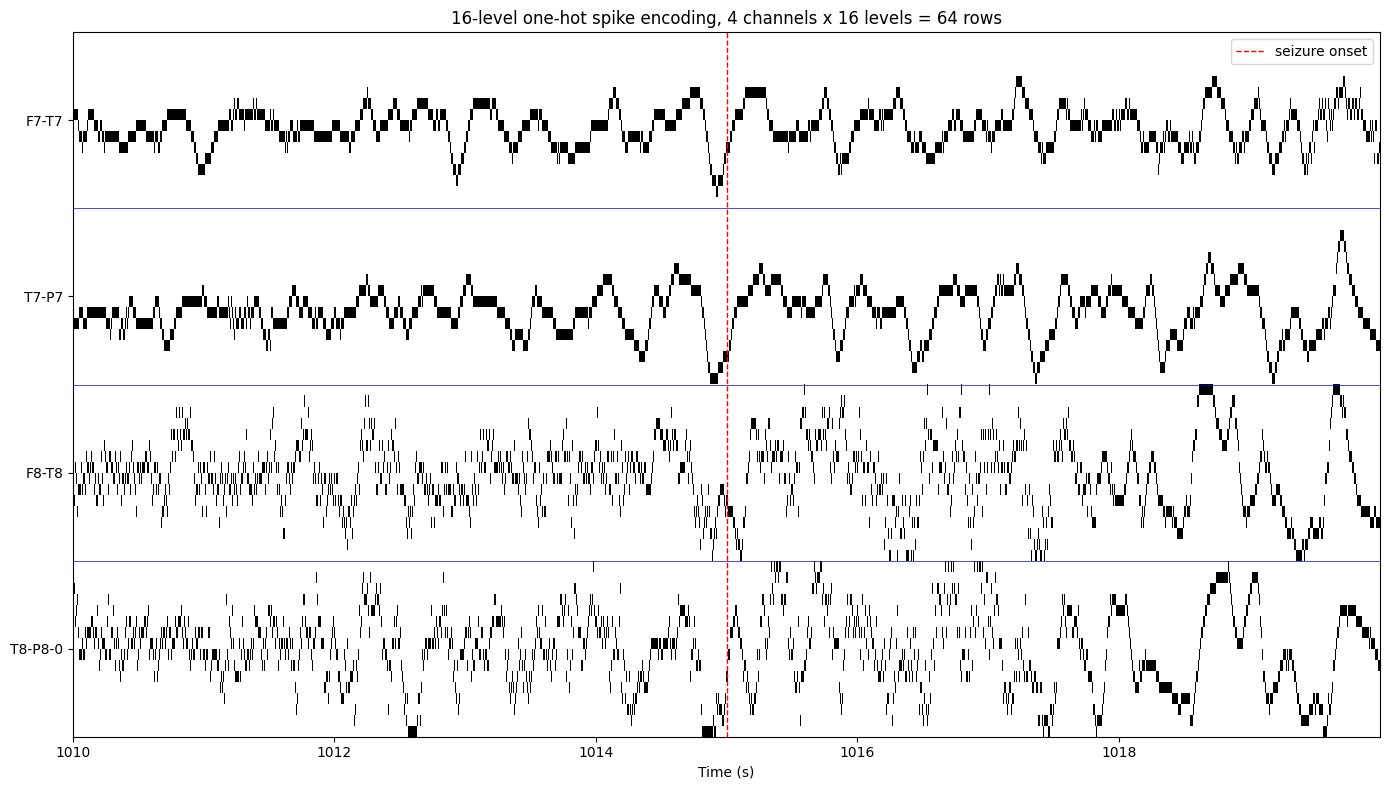

In [ ]:
# get a 10-second window from chb01_16 around seizure onset (1010-1020s)
window_data = raw_4ch.get_data(tmin=1010, tmax=1020) * 1e6  # (4, n_samples) in uV
window_times = np.arange(window_data.shape[1]) / sfreq + 1010

n_samples = window_data.shape[1]
spike_matrix = np.zeros((4 * n_levels, n_samples), dtype=int)  # 64 rows x n_samples

for ch_i in range(4):
    # digitize: returns bin index for each sample (1-indexed by default against edges)
    levels = np.digitize(window_data[ch_i], bin_edges[ch_i]) - 1
    levels = np.clip(levels, 0, n_levels - 1)  # safety clip
    for t in range(n_samples):
        row = ch_i * n_levels + levels[t]
        spike_matrix[row, t] = 1

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(spike_matrix, aspect='auto', cmap='Greys', interpolation='none',
           extent=[window_times[0], window_times[-1], 64, 0])
ax.axvline(1015, color='red', linestyle='--', linewidth=1, label='seizure onset')
for ch_i in range(4):
    ax.axhline(ch_i * n_levels, color='blue', linewidth=0.5)
ax.set_yticks([ch_i * n_levels + 8 for ch_i in range(4)])
ax.set_yticklabels(target_channels)
ax.set_xlabel('Time (s)')
ax.set_title('16-level one-hot spike encoding, 4 channels x 16 levels = 64 rows')
ax.legend()
plt.tight_layout()
plt.savefig('/content/chb01_16_spike_encoding.png', dpi=120)
plt.show()

# step 3 replicate


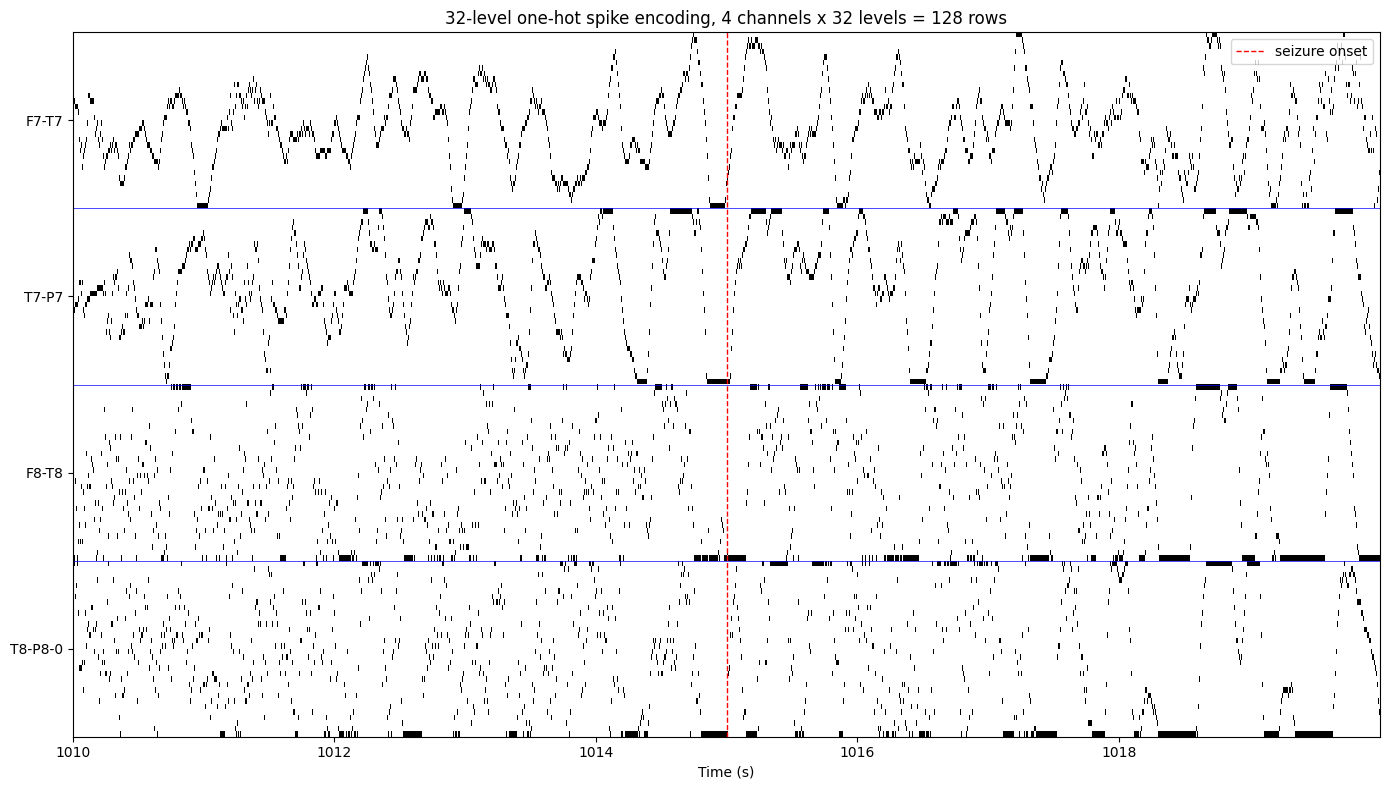

In [ ]:
# get a 10-second window from chb01_16 around seizure onset (1010-1020s)
window_data = raw_4ch.get_data(tmin=1010, tmax=1020) * 1e6  # (4, n_samples) in uV
window_times = np.arange(window_data.shape[1]) / sfreq + 1010

n_samples = window_data.shape[1]
spike_matrix = np.zeros((4 * n_levels2, n_samples), dtype=int)  # 128 rows x n_samples

for ch_i in range(4):
    # digitize: returns bin index for each sample (1-indexed by default against edges)
    levels = np.digitize(window_data[ch_i], bin_edges2[ch_i]) - 1
    levels = np.clip(levels, 0, n_levels2 - 1)  # safety clip
    for t in range(n_samples):
        row = ch_i * n_levels2 + levels[t]
        spike_matrix[row, t] = 1

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(spike_matrix, aspect='auto', cmap='Greys', interpolation='none',
           extent=[window_times[0], window_times[-1], 128, 0])
ax.axvline(1015, color='red', linestyle='--', linewidth=1, label='seizure onset')
for ch_i in range(4):
    ax.axhline(ch_i * n_levels2, color='blue', linewidth=0.5)
ax.set_yticks([ch_i * n_levels2 + 16 for ch_i in range(4)])
ax.set_yticklabels(target_channels)
ax.set_xlabel('Time (s)')
ax.set_title('32-level one-hot spike encoding, 4 channels x 32 levels = 128 rows')
ax.legend()
plt.tight_layout()
plt.savefig('/content/chb01_32_spike_encoding.png', dpi=120)
plt.show()

In [ ]:
np.save('/content/old_spike_matrix.npy', spike_matrix)
print("Saved shape:", spike_matrix.shape)

from google.colab import files
files.download('/content/old_spike_matrix.npy')

Saved shape: (128, 2560)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
np.save('/content/drive/MyDrive/old_spike_matrix.npy', spike_matrix)
print("Saved to Drive, shape:", spike_matrix.shape)

Saved to Drive, shape: (64, 2560)


# personal PSD exploration from documentaion

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_657/184638962.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_4ch.compute_psd(fmax=30).plot(picks="all", exclude="bads", amplitude=False);


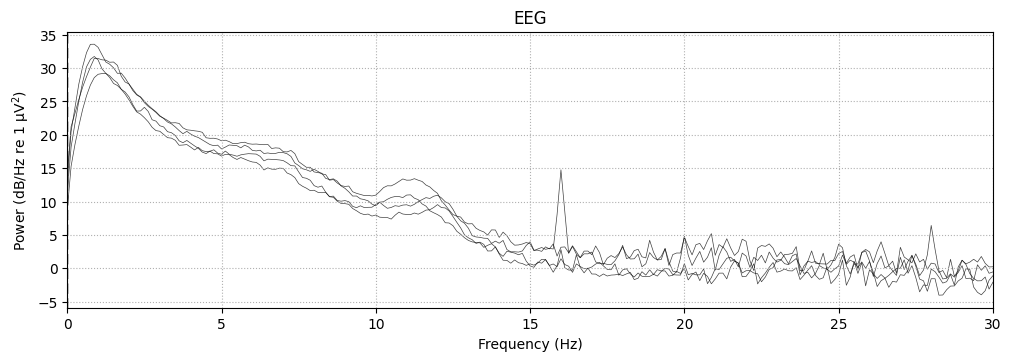

In [ ]:
raw_4ch.compute_psd(fmax=30).plot(picks="all", exclude="bads", amplitude=False);

In [ ]:
total_time = raw_4ch.times[-1]
total_time

np.float64(3599.99609375)

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


/tmp/ipykernel_657/1188490298.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_seizure.plot(picks="eeg", amplitude=False);


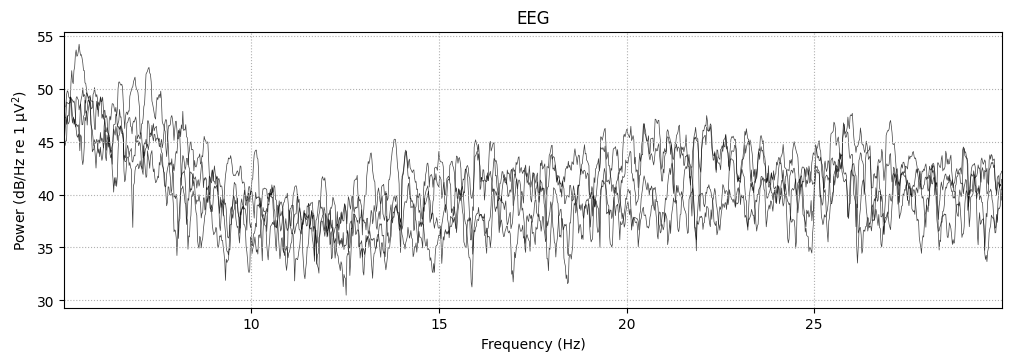

In [ ]:
psd_seizure = raw_4ch.compute_psd(method="multitaper", tmin=seizure_start, tmax=seizure_end,
                                    fmin=5, fmax=30, picks="eeg")
psd_seizure.plot(picks="eeg", amplitude=False);

In [ ]:
ica = mne.preprocessing.ICA(n_components=4, random_state=42, max_iter=800)

In [ ]:
ica.fit(raw_4ch)

Fitting ICA to data using 4 channels (please be patient, this may take a while)


/tmp/ipykernel_657/3341697052.py:1: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_4ch)


Selecting by number: 4 components
Fitting ICA took 27.8s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=800
Fit,36 iterations on raw data (921600 samples)
ICA components,4
Available PCA components,4
Channel types,eeg
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=4, n_times=921600
    Range : 0 ... 921599 =      0.000 ...  3599.996 secs
Ready.
Using matplotlib as 2D backend.


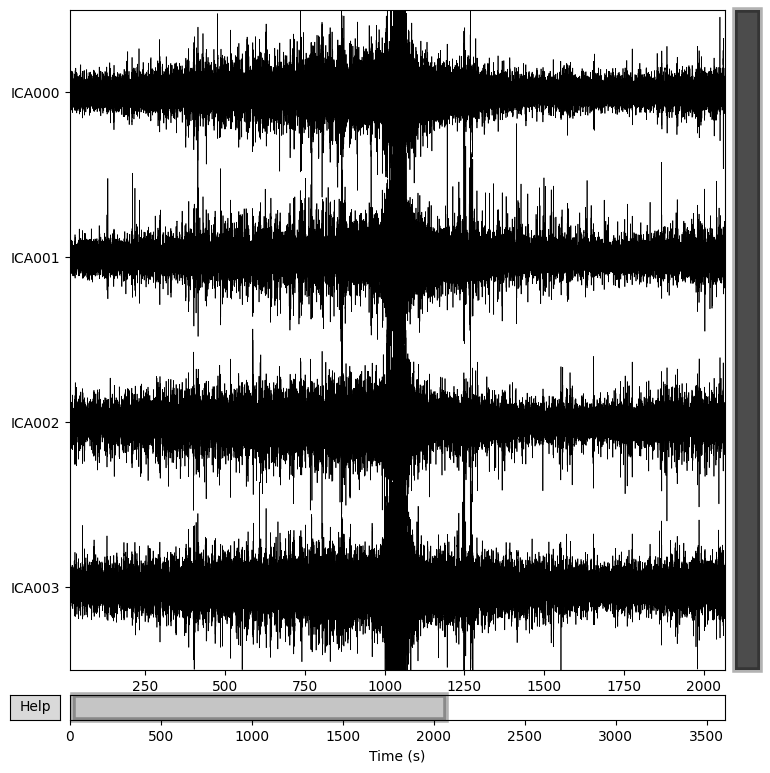

In [ ]:
ica.plot_sources(raw_4ch, start=seizure_start-1000, stop=seizure_end+1000);

In [ ]:
raw.info["ch_names"]

['FP1-F7',
 'F7-T7',
 'T7-P7',
 'P7-O1',
 'FP1-F3',
 'F3-C3',
 'C3-P3',
 'P3-O1',
 'FP2-F4',
 'F4-C4',
 'C4-P4',
 'P4-O2',
 'FP2-F8',
 'F8-T8',
 'T8-P8-0',
 'P8-O2',
 'FZ-CZ',
 'CZ-PZ',
 'P7-T7',
 'T7-FT9',
 'FT9-FT10',
 'FT10-T8',
 'T8-P8-1']

# using differnt channels to plot and also create ICA

In [ ]:
target_channels2 = ['FT9-FT10', 'F8-T8', 'FP1-F3', 'FP1-F7']

raw_4chnew = raw.copy().pick(target_channels2)
print(raw_4chnew.ch_names)

['FT9-FT10', 'F8-T8', 'FP1-F3', 'FP1-F7']


Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2121/3613472512.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_4chnew.compute_psd(fmax=30).plot(picks="all", exclude="bads", amplitude=False);


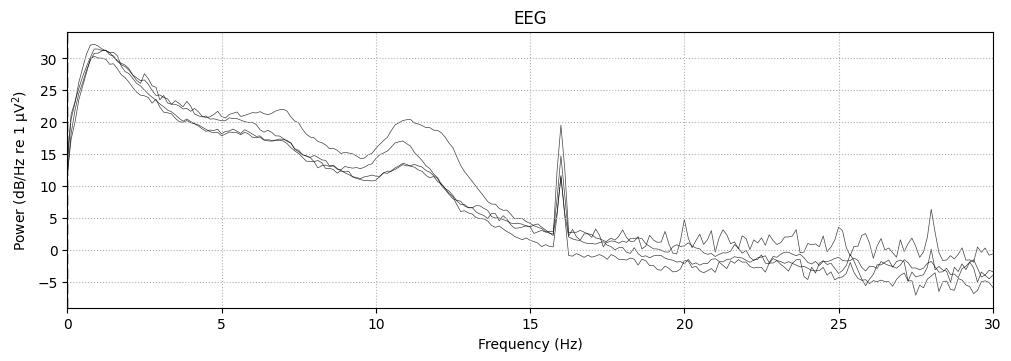

In [ ]:
raw_4chnew.compute_psd(fmax=30).plot(picks="all", exclude="bads", amplitude=False);

In [ ]:
ica2 = mne.preprocessing.ICA(n_components=4, random_state=42, max_iter=800)

In [ ]:
ica2.fit(raw_4chnew)

Fitting ICA to data using 4 channels (please be patient, this may take a while)


/tmp/ipykernel_2121/1816271011.py:1: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica2.fit(raw_4chnew)


Selecting by number: 4 components
Fitting ICA took 17.7s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=800
Fit,34 iterations on raw data (921600 samples)
ICA components,4
Available PCA components,4
Channel types,eeg
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=4, n_times=921600
    Range : 0 ... 921599 =      0.000 ...  3599.996 secs
Ready.


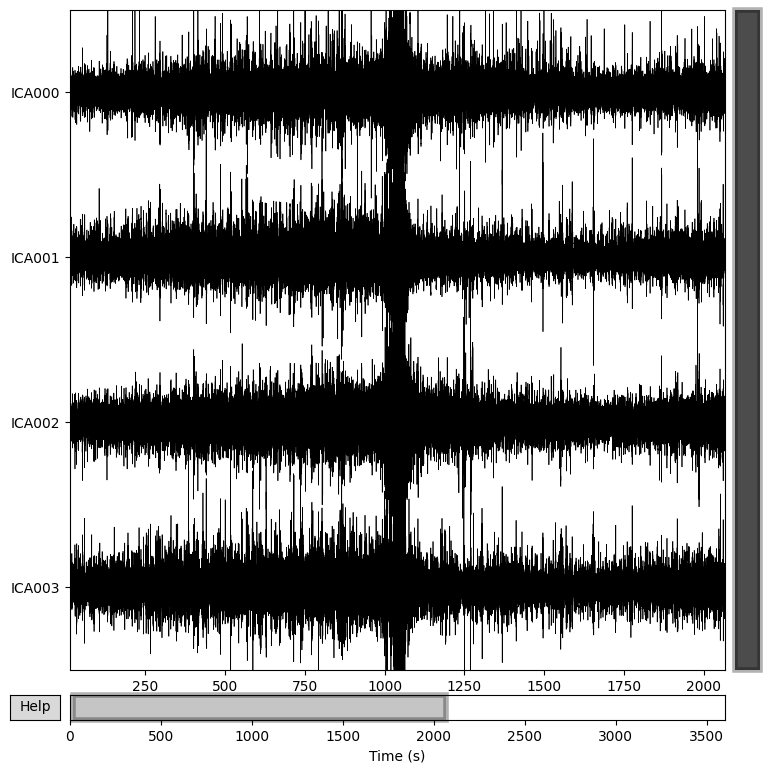

In [ ]:
ica2.plot_sources(raw_4chnew, start=seizure_start-1000, stop=seizure_end+1000);

Creating RawArray with float64 data, n_channels=4, n_times=921600
    Range : 0 ... 921599 =      0.000 ...  3599.996 secs
Ready.


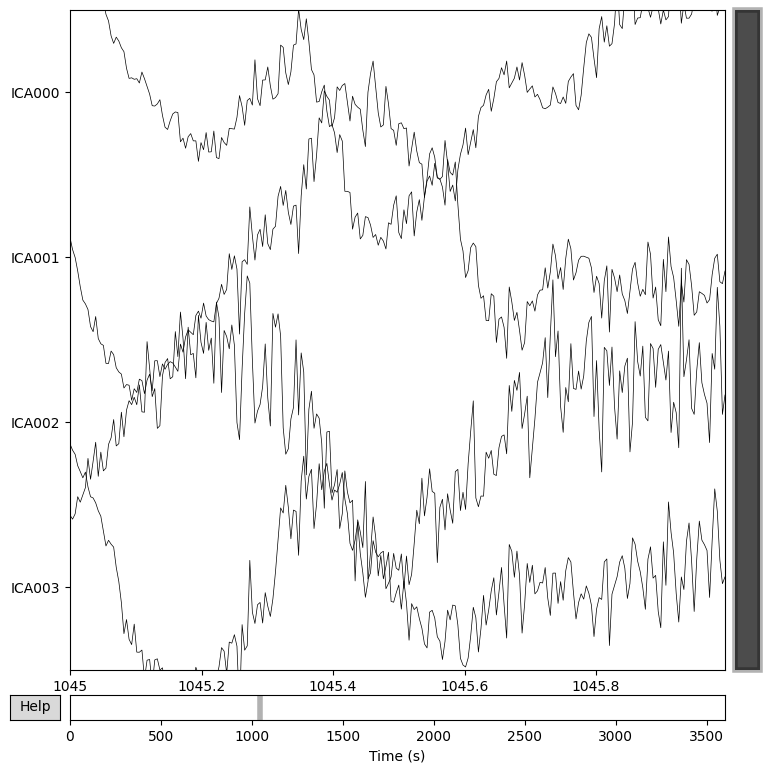

In [ ]:
ica2.plot_sources(raw_4chnew, start=seizure_start+30, stop=seizure_end-20);

In [ ]:
seizure_end - seizure_start

51

Creating RawArray with float64 data, n_channels=4, n_times=921600
    Range : 0 ... 921599 =      0.000 ...  3599.996 secs
Ready.


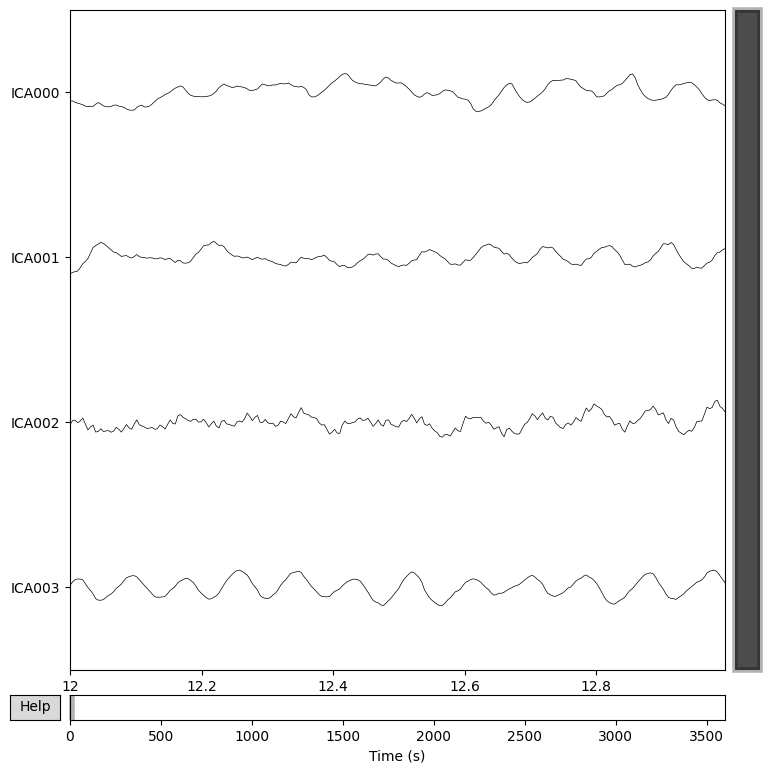

In [ ]:
# Plot the hidden ICA components unfolding over time
ica2.plot_sources(raw, start=12, stop=13);

# ICA of complete raw

In [ ]:
ica3 = mne.preprocessing.ICA(n_components=23,random_state = 42, max_iter = 800)

In [ ]:
raw2 = raw.copy()

In [ ]:
ica3.fit(raw2)

Fitting ICA to data using 23 channels (please be patient, this may take a while)


/tmp/ipykernel_2121/1362244316.py:1: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica3.fit(raw2)


Selecting by number: 23 components


Creating RawArray with float64 data, n_channels=23, n_times=921600
    Range : 0 ... 921599 =      0.000 ...  3599.996 secs
Ready.


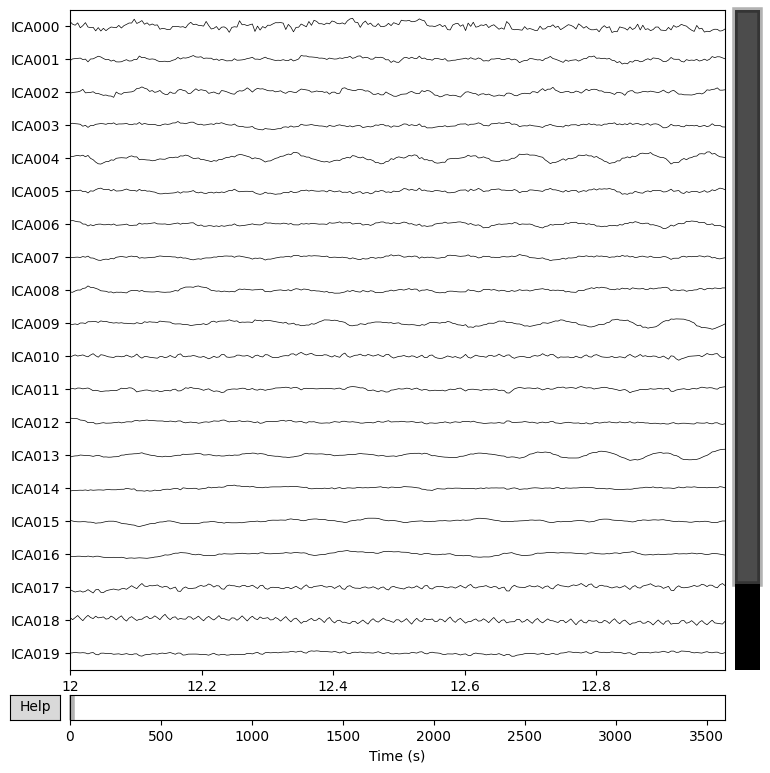

In [ ]:
ica3.plot_sources(raw2, start=12, stop=13);

Creating RawArray with float64 data, n_channels=23, n_times=921600
    Range : 0 ... 921599 =      0.000 ...  3599.996 secs
Ready.


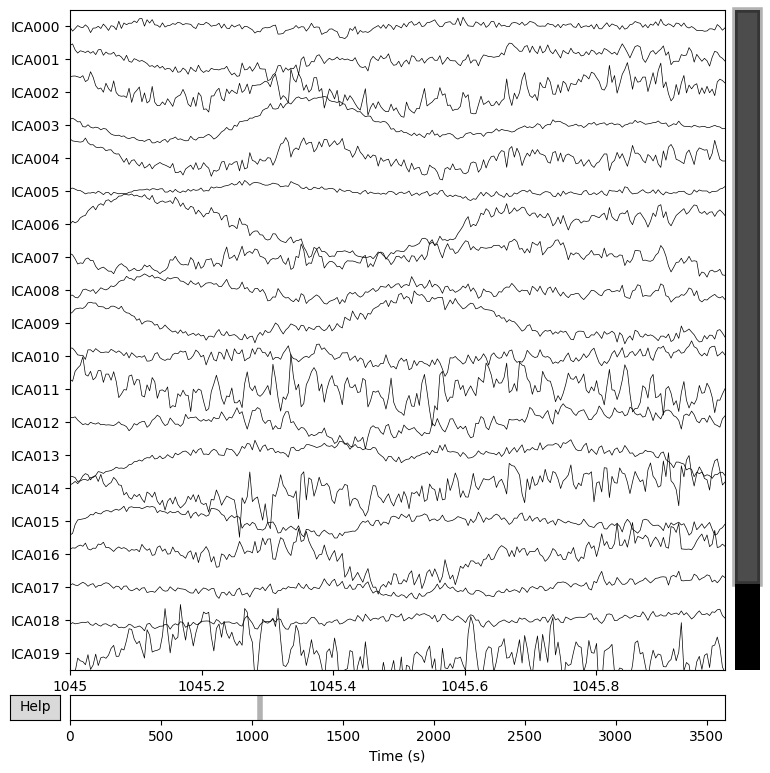

In [ ]:
ica3.plot_sources(raw2, start=seizure_start+30, stop=seizure_end-20);

In [ ]:
ica3.exclude = [5]

In [ ]:
ica3.apply(raw2)

Applying ICA to Raw instance
    Transforming to ICA space (23 components)
    Zeroing out 1 ICA component
    Projecting back using 23 PCA components


<RawEDF | chb01_16.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [ ]:
del ica3

In [ ]:
ica3.plot_sources(raw2, start=seizure_start+30, stop=seizure_end-20);

NameError: name 'ica3' is not defined

# notch filtering

Notching frequencies: [ 60 120]
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.000 (s)


/tmp/ipykernel_2121/61650497.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_before.plot(picks="eeg", amplitude=False, axes=axes[0], show=False)


Plotting power spectral density (dB=True).


/tmp/ipykernel_2121/61650497.py:18: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_after.plot(picks="eeg", amplitude=False, axes=axes[1], show=False)


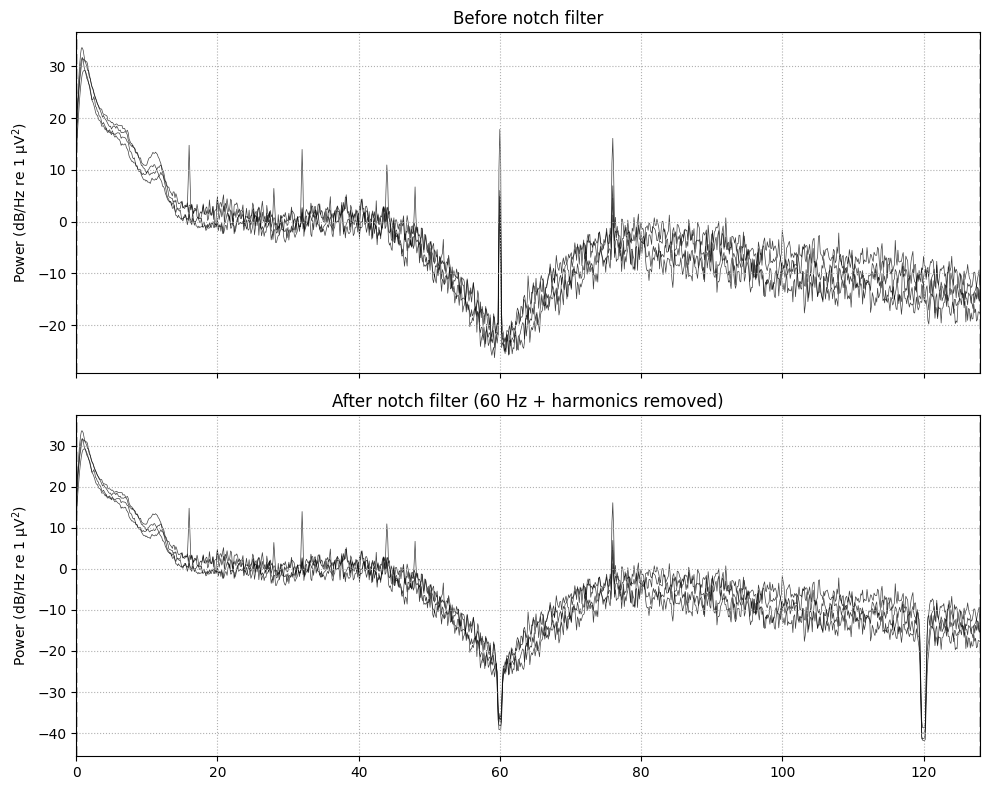

In [ ]:
# work on a copy so raw stays untouched
raw_notch = raw_4ch.copy()

# notch out 60 Hz and its harmonics (up to Nyquist, 128 Hz)
freqs_to_notch = np.arange(60, 128, 60)  # 60, 120
print("Notching frequencies:", freqs_to_notch)

raw_notch.notch_filter(freqs=freqs_to_notch, picks='eeg')

# compare PSD before vs after, full record, same as your first plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

psd_before = raw_4ch.compute_psd(fmax=128)
psd_before.plot(picks="eeg", amplitude=False, axes=axes[0], show=False)
axes[0].set_title("Before notch filter")

psd_after = raw_notch.compute_psd(fmax=128)
psd_after.plot(picks="eeg", amplitude=False, axes=axes[1], show=False)
axes[1].set_title("After notch filter (60 Hz + harmonics removed)")

plt.tight_layout()
plt.savefig('/content/chb01_16_notch_comparison.png', dpi=120)
plt.show()

In [ ]:
# reject criteria: loosen vs tutorial's 150uV since seizure amplitudes reach ~600uV legitimately
reject_criteria = dict(eeg=800e-6)  # 800 µV, generous enough not to reject real seizure activity

epochs = mne.Epochs(
    raw_4ch,
    events,
    event_id=event_dict,
    tmin=-0.5,
    tmax=0.5,
    reject=reject_criteria,
    baseline=None,   # no meaningful pre-stimulus baseline here, unlike auditory/visual tutorial
    preload=True,
)

print(epochs)
epochs.equalize_event_counts(['seizure', 'normal'])

seizure_epochs = epochs['seizure']
normal_epochs = epochs['normal']

print(f"\nSeizure epochs: {len(seizure_epochs)}, Normal epochs: {len(normal_epochs)}")

Not setting metadata
151 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 151 events and 257 original time points ...
    Rejecting  epoch based on EEG : ['F8-T8', 'T8-P8-0']
    Rejecting  epoch based on EEG : ['F8-T8']
    Rejecting  epoch based on EEG : ['F8-T8', 'T8-P8-0']
    Rejecting  epoch based on EEG : ['F8-T8']
    Rejecting  epoch based on EEG : ['F8-T8']
5 bad epochs dropped
<Epochs | 146 events (all good), -0.5 – 0.5 s (baseline off), ~1.2 MiB, data loaded,
 'seizure': 21
 'normal': 125>
Dropped 104 epochs: 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 

/tmp/ipykernel_2121/2456491751.py:4: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


In [ ]:
target_channels = ['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']

Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
21 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2121/3649371014.py:5: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  seizure_epochs.plot_image(picks=target_channels)
/tmp/ipykernel_2121/3649371014.py:5: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  seizure_epochs.plot_image(picks=target_channels)
/tmp/ipykernel_2121/3649371014.py:5: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  seizure_epochs.plot_image(picks=target_channels)
/tmp/ipykernel_2121/3649371014.py:5: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  seizure_epochs.plot_image(picks=target_channels)


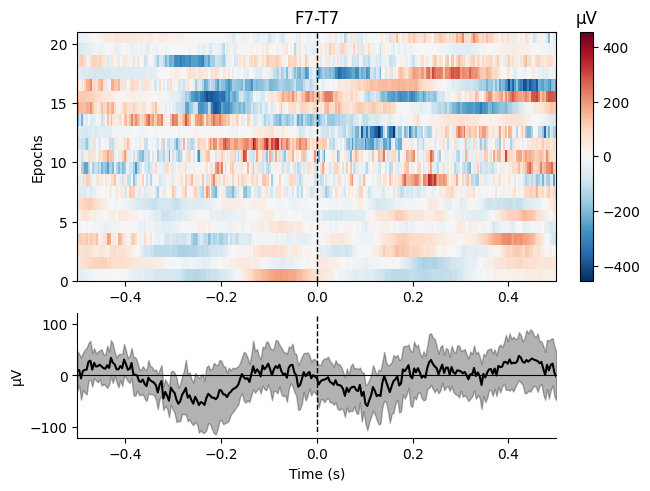

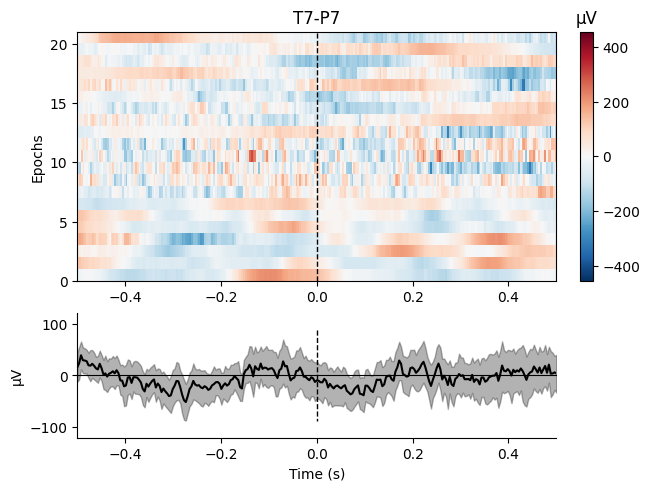

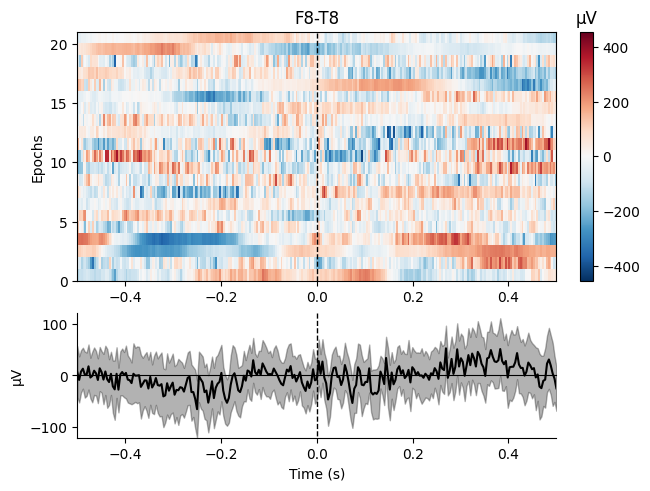

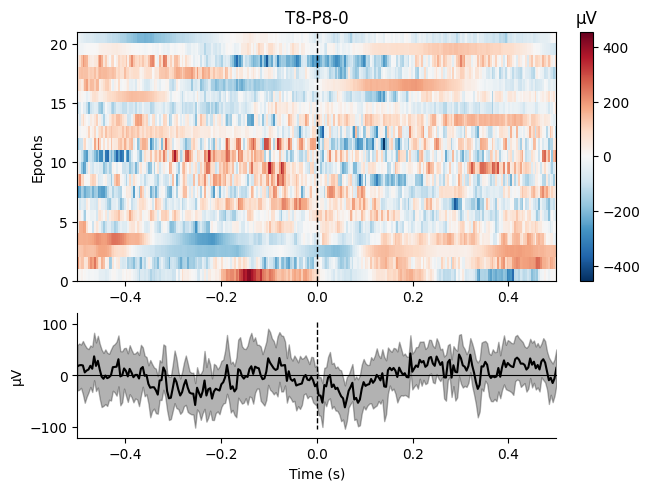

[<Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 3 Axes>,
 <Figure size 640x480 with 3 Axes>]

In [ ]:
seizure_evoked = seizure_epochs.average()
normal_evoked = normal_epochs.average()

# plot_image first - shows each individual epoch as a row, per channel
seizure_epochs.plot_image(picks=target_channels)